# IRI dynamic threshold check

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar
import ocha_stratus as stratus
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.special import expit  # logistic function


from src.constants import *

In [3]:
blob_name = f"{PROJECT_PREFIX}/processed/iri_cerf_stats.parquet"
df_stats_iri = stratus.load_parquet_from_blob(blob_name)

In [4]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/chirps/chirps_dek_season_cumul.parquet"
)
df_chirps_raw = stratus.load_parquet_from_blob(blob_name)

In [5]:
df_chirps_final = df_chirps_raw[df_chirps_raw["dekad_overall"] == 27]

In [6]:
df_stats_iri = df_stats_iri.merge(
    df_chirps_final[["year", "rfh_all_cumul", "rfh_aoi_cumul"]]
)

In [7]:
df_stats_iri

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$,rfh_all_cumul,rfh_aoi_cumul
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,0.0,NaN,60.121881,210.054397
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,0.0,NaN,51.311365,166.521189
2,1993,32.6,37.6,33.9,37.2,38.3,47.5,16.0,None,70.4,0.0,NaN,68.003672,188.646425
3,1994,32.3,32.8,35.3,42.0,43.8,39.4,16.0,None,80.7,0.0,NaN,78.242482,236.755851
4,1995,33.7,31.6,24.5,30.8,31.3,27.2,16.0,None,91.1,0.0,NaN,88.517791,273.407340
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,0.0,NaN,58.703547,190.209995
6,1997,34.2,39.6,42.4,28.9,36.1,41.3,16.0,None,71.2,0.0,NaN,68.987787,199.148639
7,1998,32.8,26.8,33.0,25.8,30.6,27.5,16.0,None,85.0,0.0,NaN,82.569926,239.673621
8,1999,36.3,31.3,35.8,40.3,27.5,25.7,30.0,None,99.1,0.0,NaN,95.462707,333.540164
9,2000,36.1,32.9,32.5,27.7,35.4,28.0,16.0,None,76.7,0.0,NaN,74.087495,278.465525


In [9]:
df_model = df_stats_iri.copy()

In [69]:
start_year = 1991 + 5

In [70]:
df_wf_trigs

,current_year,thresh,trig
0,2000,39.995,False
1,2001,39.750,False
2,2002,39.505,False
3,2003,38.540,False
4,2004,37.035,False
5,2005,35.530,False
6,2006,34.875,False
7,2007,34.560,False
8,2008,34.245,False
9,2009,34.830,True


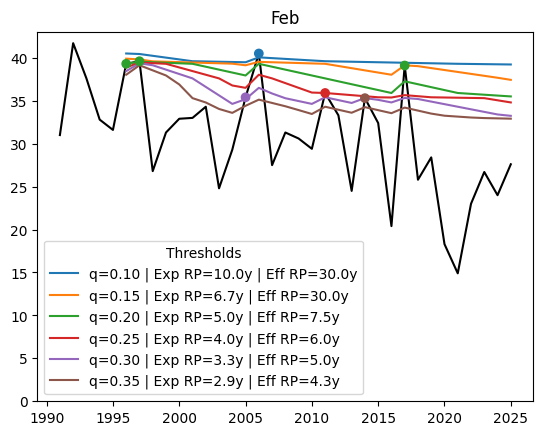

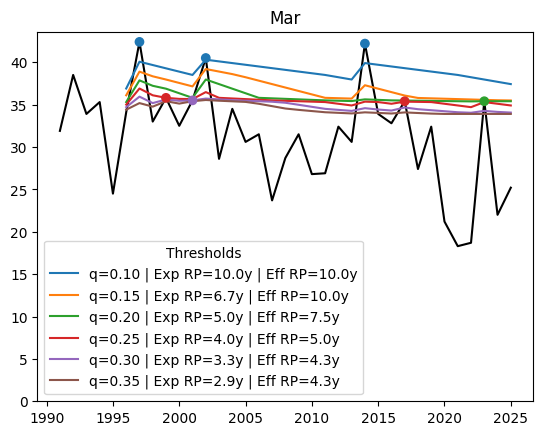

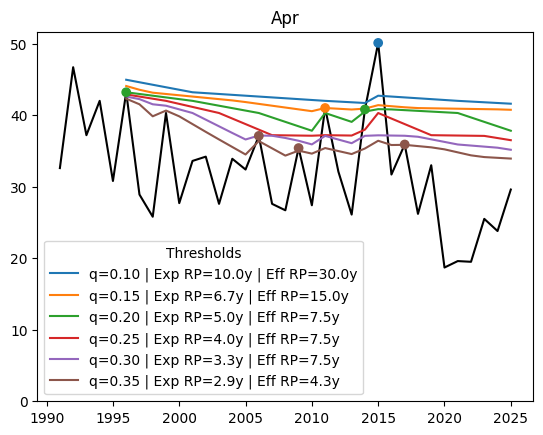

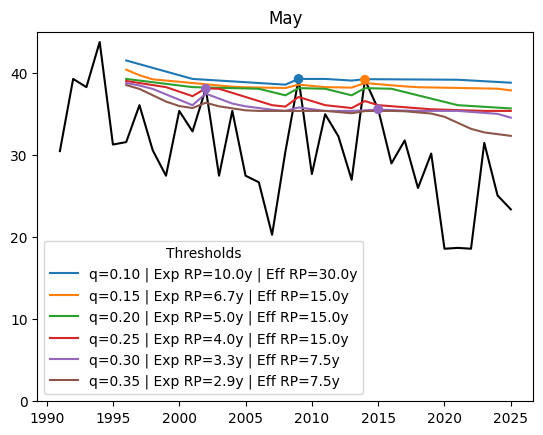

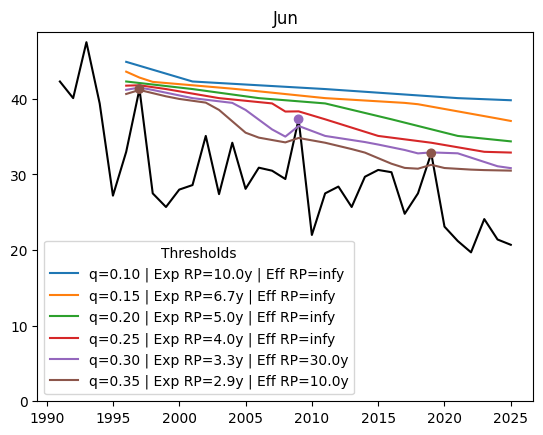

In [71]:
import matplotlib.pyplot as plt
import pandas as pd
import calendar

quantiles = sorted([0.1, 0.15, 0.2, 0.25, 0.3, 0.35])
rp_dicts = []

for mo in range(2, 7):
    col = calendar.month_abbr[mo]

    fig, ax = plt.subplots()

    # plot underlying time series WITHOUT legend entry
    ax.plot(
        df_model["year"],
        df_model[col],
        color="k",
        label="_nolegend_",  # suppress legend
    )

    thresh_results = {}
    thresh_colors = {}

    for quantile in quantiles:

        dicts = []

        for current_year in range(start_year, 2026):
            df_past = df_model[df_model["year"] <= current_year]
            if df_past.empty:
                continue

            current_row = df_model.set_index("year").loc[current_year]

            thresh = df_past[col].quantile(1 - quantile)
            trig = current_row[col] >= thresh

            dicts.append(
                {
                    "current_year": current_year,
                    "thresh": thresh,
                    "trig": trig,
                }
            )

        df_wf_trigs = pd.DataFrame(dicts)

        total_trigs = df_wf_trigs["trig"].sum()
        n_years = len(df_wf_trigs)
        rp_eff = n_years / total_trigs if total_trigs > 0 else float("inf")

        rp_dicts.append({"mo": mo, "q": quantile, "rp_eff": rp_eff})

        color = ax._get_lines.get_next_color()

        thresh_results[quantile] = df_wf_trigs
        thresh_colors[quantile] = color

        expected_rp = 1 / quantile

        ax.plot(
            df_wf_trigs["current_year"],
            df_wf_trigs["thresh"],
            color=color,
            label=(
                f"q={quantile:.2f} | "
                f"Exp RP={expected_rp:.1f}y | "
                f"Eff RP={rp_eff:.1f}y"
            ),
        )

    # ---- determine marker color (lowest quantile trigger) ----

    years = thresh_results[quantiles[0]]["current_year"]

    marker_years = []
    marker_vals = []
    marker_colors = []

    df_indexed = df_model.set_index("year")

    for year in years:
        val = df_indexed.loc[year, col]

        chosen_color = None

        for quantile in quantiles:  # lowest first
            df_q = thresh_results[quantile]
            if df_q.loc[df_q["current_year"] == year, "trig"].values[0]:
                chosen_color = thresh_colors[quantile]
                break

        if chosen_color is not None:
            marker_years.append(year)
            marker_vals.append(val)
            marker_colors.append(chosen_color)

    ax.scatter(
        marker_years,
        marker_vals,
        c=marker_colors,
        zorder=5,
    )

    ax.set_ylim(bottom=0)
    ax.set_title(f"{col}")
    ax.legend(title="Thresholds")

df_mo_rps = pd.DataFrame(rp_dicts)

In [72]:
df_mo_rps["rp_nom"] = 1 / df_mo_rps["q"]

[None, None]

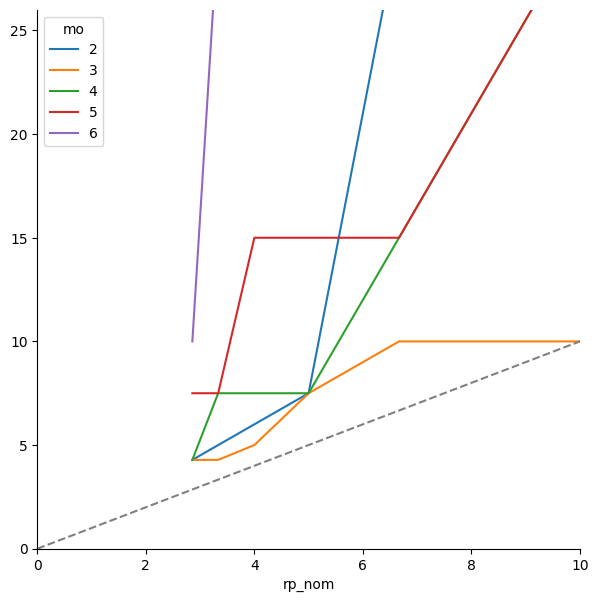

In [73]:
fig, ax = plt.subplots(figsize=(7, 7))

df_mo_rps.pivot(columns="mo", values="rp_eff", index="rp_nom").plot(ax=ax)

ax.plot([0, 26], [0, 26], linestyle="--", color="grey")

ax.set_ylim(bottom=0, top=26)
ax.set_xlim(left=0, right=df_mo_rps["rp_nom"].max())

[ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [68]:
def highlight_trigger(val):
    if val:
        return "background-color: crimson; color: white"
    return ""

In [ ]:
col = "Jun"

dyn_q = 0.35